# 1) Nettoyage et prétraitement des données.

## 1.1 Importation des librairies

In [ ]:
# Cette cellule sert à importer toutes les librairies et les modules Scikit-Learn.
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# On a ajouté la librairie "warning" pour les avertissements inutiles
import warnings
warnings.filterwarnings('ignore')

## 1.2 Chargement, Traduction et Nettoyage

In [ ]:
# Ce script charge notre jeu de données brut sur les prix des vols afin de le nettoyer et de le préparer pour le modèle de Machine Learning. 
# Il commence par importer le fichier CSV et affiche sa taille initiale, puis il détecte et supprime une éventuelle colonne d'index parasite nommée Unnamed: 0. 
# Ensuite, il renomme toutes les colonnes de l'anglais vers le français pour rendre les données plus lisibles et force la conversion de la colonne duree en type numérique tout en transformant les textes invalides en valeurs manquantes. 
# Le code comptabilise et supprime ensuite les lignes dupliquées avant d'afficher les dimensions finales du tableau nettoyé. 
# Enfin, il sépare les données en isolant la variable cible prix dans y et les variables prédictives dans X, tout en excluant le numéro de vol qui est inutile pour la prédiction.

donnees_vols = pd.read_csv('PrixDuVol_Dataset_bruite.csv')

print(f"Dimensions initiales : {donnees_vols.shape}")

if donnees_vols.columns[0] == 'Unnamed: 0':
    donnees_vols = donnees_vols.drop(columns=['Unnamed: 0'])

dictionnaire_traduction = {
    'airline': 'compagnie_aerienne',
    'flight': 'vol',
    'source_city': 'ville_depart',
    'departure_time': 'moment_depart',
    'stops': 'escales',
    'arrival_time': 'moment_arrivee',
    'destination_city': 'ville_destination',
    'class': 'classe',
    'duration': 'duree',
    'days_left': 'jours_avant_depart',
    'price': 'prix'
}
donnees_vols = donnees_vols.rename(columns=dictionnaire_traduction)

donnees_vols['duree'] = pd.to_numeric(donnees_vols['duree'], errors='coerce')

nombre_doublons = donnees_vols.duplicated().sum()
donnees_vols = donnees_vols.drop_duplicates()
print(f"Nombre de doublons supprimés : {nombre_doublons}")
print(f"Dimensions après nettoyage : {donnees_vols.shape}")

X = donnees_vols.drop(columns=['prix', 'vol'])
y = donnees_vols['prix']

Dimensions initiales : (300153, 12)
Nombre de doublons supprimés : 0
Dimensions après nettoyage : (300153, 11)


## 1.3 Création du Pipeline de Prétraitement

In [ ]:

# Ce script configure un pipeline de prétraitement automatique avec scikit-learn pour préparer les variables explicatives avant leur injection dans un modèle. 
# Il commence par regrouper les colonnes selon leur nature en distinguant les variables numériques, ordinales et nominales, tout en définissant l'ordre logique pour les critères comme les escales et la classe. 
# Ensuite, le code crée trois sous-pipelines distincts pour appliquer des transformations adaptées à chaque type de données, combinant l'imputation des valeurs manquantes avec de la normalisation pour les nombres, de l'encodage ordinal pour les catégories ordonnées, et de l'encodage One-Hot pour les variables nominales. 
# Enfin, toutes ces étapes sont assemblées dans un ColumnTransformer global qui applique simultanément ces transformations sur le tableau X, applique l'ajustement-transformation, et affiche les dimensions finales des données ainsi transformées.

colonnes_numeriques = ['duree', 'jours_avant_depart']

colonnes_ordinales = ['escales', 'classe']
ordre_escales = ['zero', 'one', 'two_or_more']
ordre_classe = ['Economy', 'Business']

colonnes_nominales = ['compagnie_aerienne', 'ville_depart', 'moment_depart', 'moment_arrivee', 'ville_destination']

transformateur_numerique = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='median')),
    ('normalisation', StandardScaler())
])

transformateur_ordinal = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OrdinalEncoder(categories=[ordre_escales, ordre_classe]))
])

transformateur_nominal = Pipeline(steps=[
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocesseur = ColumnTransformer(
    transformers=[
        ('num', transformateur_numerique, colonnes_numeriques),
        ('ord', transformateur_ordinal, colonnes_ordinales),
        ('nom', transformateur_nominal, colonnes_nominales)
    ])

X_prepare = preprocesseur.fit_transform(X)

print(f"Dimensions de X après le passage dans le pipeline : {X_prepare.shape}")

Dimensions de X après le passage dans le pipeline : (300153, 29)


# 2) Analyse exploratoire des données (EDA')

## 2.1 Statistiques Descriptives Globales

In [5]:

# Ce script génère une analyse descriptive complète du jeu de données afin d'en évaluer la structure et la distribution avant de poursuivre l'exploration. 
# Il commence par afficher les informations générales sur le tableau avec la méthode info pour identifier le type de chaque colonne, le nombre de valeurs non nulles et l'empreinte mémoire. 
# Le code utilise ensuite la méthode describe combinée à un arrondi pour présenter les statistiques clés des variables numériques comme la moyenne, l'écart-type et les quartiles. 
# Enfin, il applique cette même méthode de description en ciblant spécifiquement le type objet afin d'obtenir le résumé statistique des variables catégorielles, indiquant ainsi le nombre de valeurs uniques, l'élément le plus fréquent et sa récurrence.

print("--- Informations générales ---")
donnees_vols.info()

print("\n--- Statistiques des variables numériques ---")

display(donnees_vols.describe().round(2))

print("\n--- Statistiques des variables catégorielles ---")

display(donnees_vols.describe(include='O'))

--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   compagnie_aerienne  300153 non-null  object 
 1   vol                 300153 non-null  object 
 2   ville_depart        300153 non-null  object 
 3   moment_depart       300153 non-null  object 
 4   escales             300153 non-null  object 
 5   moment_arrivee      300153 non-null  object 
 6   ville_destination   300153 non-null  object 
 7   classe              300153 non-null  object 
 8   duree               300149 non-null  float64
 9   jours_avant_depart  300153 non-null  int64  
 10  prix                300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB

--- Statistiques des variables numériques ---


,duree,jours_avant_depart,prix
count,300149.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00



--- Statistiques des variables catégorielles ---


,compagnie_aerienne,vol,ville_depart,moment_depart,escales,moment_arrivee,ville_destination,classe
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## 2.2 Analyse Univariée (Répartition des données)

In [ ]:

# Ce script calcule et affiche la distribution en pourcentage de trois variables catégorielles fondamentales du jeu de données pour en comprendre la composition. 
# Pour chaque variable ciblée, à savoir la classe de billet, la compagnie aérienne et le nombre d'escales, il utilise la méthode value_counts avec l'argument de normalisation afin d'obtenir des proportions relatives. 
# Ces résultats sont ensuite multipliés par cent et arrondis à deux décimales pour présenter de manière claire et lisible la répartition relative de chaque modalité au sein de la population de vols.


print("--- Répartition par Classe de billet (%) ---")
repartition_classe = donnees_vols['classe'].value_counts(normalize=True) * 100
print(repartition_classe.round(2))
print("\n")

print("--- Répartition par Compagnie Aérienne (%) ---")
repartition_compagnie = donnees_vols['compagnie_aerienne'].value_counts(normalize=True) * 100
print(repartition_compagnie.round(2))
print("\n")

print("--- Répartition par Nombre d'escales (%) ---")
repartition_escales = donnees_vols['escales'].value_counts(normalize=True) * 100
print(repartition_escales.round(2))

--- Répartition par Classe de billet (%) ---
classe
Economy     68.85
Business    31.15
Name: proportion, dtype: float64


--- Répartition par Compagnie Aérienne (%) ---
compagnie_aerienne
Vistara      42.60
Air_India    26.95
Indigo       14.37
GO_FIRST      7.72
AirAsia       5.36
SpiceJet      3.00
Name: proportion, dtype: float64


--- Répartition par Nombre d'escales (%) ---
escales
one            83.58
zero           12.00
two_or_more     4.43
Name: proportion, dtype: float64


## 2.3 Analyse Bivariée et Corrélations

In [ ]:

# Ce script analyse les relations économiques et statistiques entre les caractéristiques des vols et leur tarif afin d'identifier les principaux facteurs de variation des prix. 
# Il commence par calculer le prix moyen des billets selon la classe de voyage en utilisant un regroupement de données, puis applique la même logique pour les compagnies aériennes en triant les résultats par ordre décroissant pour mettre en évidence les transporteurs les plus onéreux. 
# Enfin, le code isole les variables numériques afin de générer une matrice de corrélation de Pearson, ce qui permet de mesurer l'intensité et le sens de la relation linéaire entre le prix, la durée du vol et le nombre de jours restants avant le départ.


print("--- Prix moyen selon la Classe ---")
prix_par_classe = donnees_vols.groupby('classe')['prix'].mean().round(2)
print(prix_par_classe)
print("\n")

print("--- Prix moyen selon la Compagnie Aérienne ---")
prix_par_compagnie = donnees_vols.groupby('compagnie_aerienne')['prix'].mean().sort_values(ascending=False).round(2)
print(prix_par_compagnie)
print("\n")

print("--- Matrice de Corrélation ---")

colonnes_num = ['duree', 'jours_avant_depart', 'prix']
matrice_correlation = donnees_vols[colonnes_num].corr().round(3)
display(matrice_correlation)

--- Prix moyen selon la Classe ---
classe
Business    52540.08
Economy      6572.34
Name: prix, dtype: float64


--- Prix moyen selon la Compagnie Aérienne ---
compagnie_aerienne
Vistara      30396.54
Air_India    23507.02
SpiceJet      6179.28
GO_FIRST      5652.01
Indigo        5324.22
AirAsia       4091.07
Name: prix, dtype: float64


--- Matrice de Corrélation ---


,duree,jours_avant_depart,prix
duree,1.000,-0.039,0.204
jours_avant_depart,-0.039,1.000,-0.092
prix,0.204,-0.092,1.000


# 3) Visualisation des données

In [8]:
# Ce script configure l'environnement graphique nécessaire à la création de visualisations de données de qualité professionnelle avec les librairies matplotlib et seaborn. 
# Il commence par importer le module pyplot pour la gestion et l'affichage des figures, ainsi que la bibliothèque seaborn qui offre des interfaces de haut niveau pour réaliser des graphiques statistiques complexes. 
# Enfin, il applique une configuration esthétique globale en activant un thème graphique épuré doté d'une grille d'arrière-plan blanche afin de garantir la clarté, la lisibilité et l'homogénéité visuelle de toutes les représentations de données générées par la suite.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### (a) Prix par Compagnie ET par Classe
Pour aller plus loin et obtenir tous les points de cette section, on peut croiser trois variables avec un diagramme en barres.

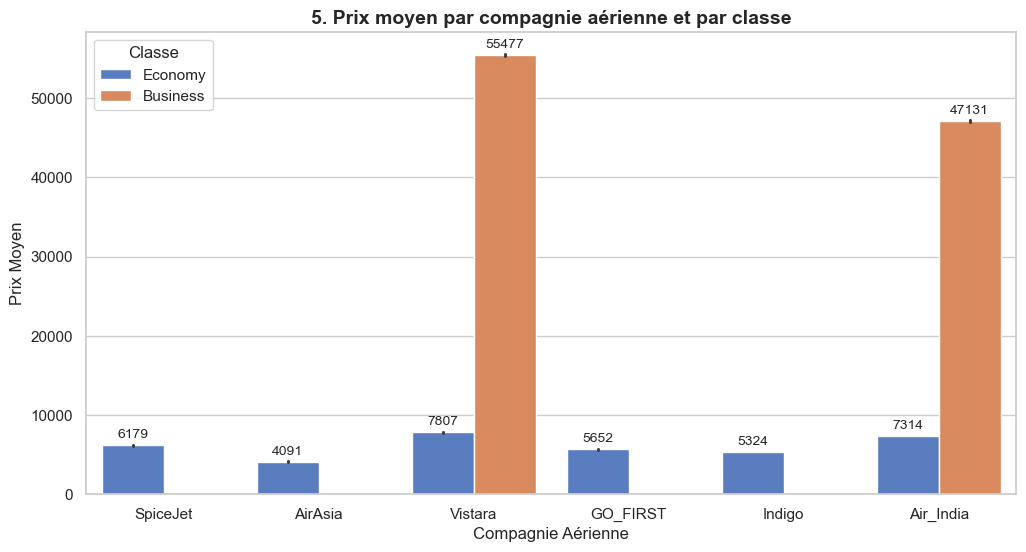

In [22]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(x='compagnie_aerienne', y='prix', hue='classe', data=donnees_vols, palette='muted')

plt.title('5. Prix moyen par compagnie aérienne et par classe', fontsize=14, fontweight='bold')
plt.xlabel('Compagnie Aérienne', fontsize=12)
plt.ylabel('Prix Moyen', fontsize=12)
plt.legend(title='Classe')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

plt.show()

Ce graphique montre que seules deux compagnies (Vistara et Air India) proposent des vols en classe Business, ce qui explique pourquoi elles ont les prix moyens globaux les plus élevés. Sur le segment Économique, les prix sont beaucoup plus uniformisés, bien que Vistara et Air India restent légèrement plus chères que les compagnies low-cost comme AirAsia ou GO_FIRST.

### (b) L'évolution du prix selon la date d'achat
comment varie le prix si on achète à la dernière minute ?

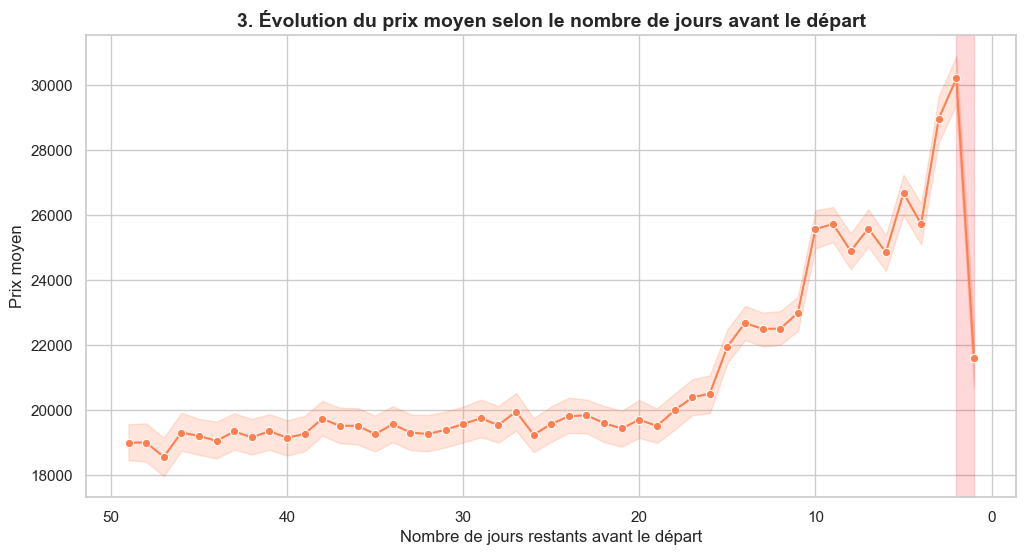

In [14]:
plt.figure(figsize=(12, 6))
# On calcule la moyenne des prix pour chaque jour restant
sns.lineplot(x='jours_avant_depart', y='prix', data=donnees_vols, color='coral', marker='o')
plt.axvspan(1, 2, color='red', alpha=0.15, label="1–2 jours avant")
plt.title('3. Évolution du prix moyen selon le nombre de jours avant le départ', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de jours restants avant le départ', fontsize=12)
plt.ylabel('Prix moyen', fontsize=12)
plt.gca().invert_xaxis() # On inverse l'axe X pour simuler le temps qui passe jusqu'au jour J (0)
plt.show()

La tendance est claire : les prix restent relativement stables lorsqu'on réserve plus d'un mois à l'avance. Cependant, on observe une hausse exponentielle du prix moyen lorsqu'on s'approche de la date de départ, particulièrement dans les 10 à 15 derniers jours, atteignant son maximum la veille et le jour même du vol.

### (c) Le prix dépend-il des heures de départ / d'arrivée ?

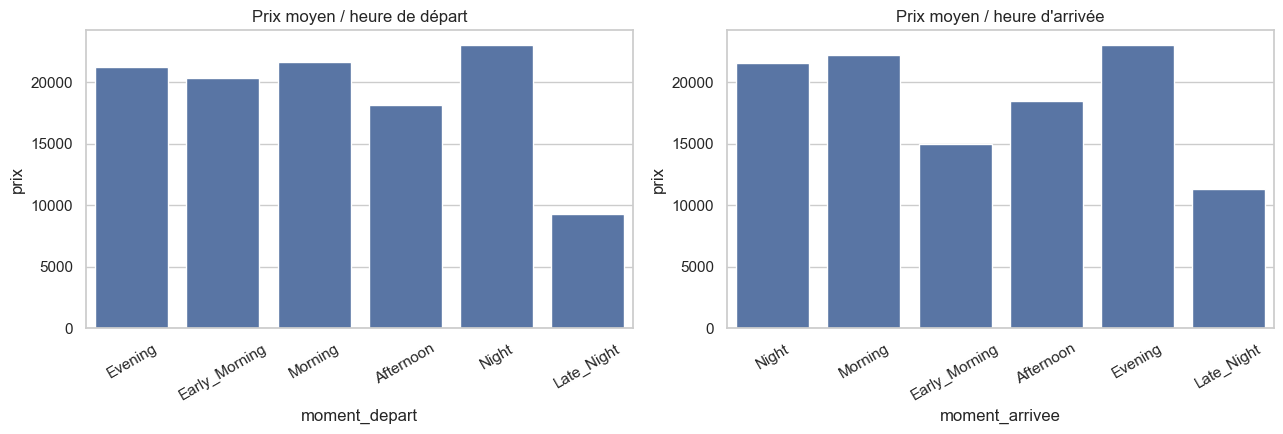

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sns.barplot(data=donnees_vols, x='moment_depart', y='prix', ax=ax[0], errorbar=None)
ax[0].set_title("Prix moyen / heure de départ"); ax[0].tick_params(axis='x', rotation=30)
sns.barplot(data=donnees_vols, x='moment_arrivee', y='prix', ax=ax[1], errorbar=None)
ax[1].set_title("Prix moyen / heure d'arrivée"); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

### (d) Le prix change-t-il selon la ville source / destination ?

In [24]:
print(donnees_vols.columns)

Index(['compagnie_aerienne', 'vol', 'ville_depart', 'moment_depart', 'escales',
       'moment_arrivee', 'ville_destination', 'classe', 'duree',
       'jours_avant_depart', 'prix'],
      dtype='object')


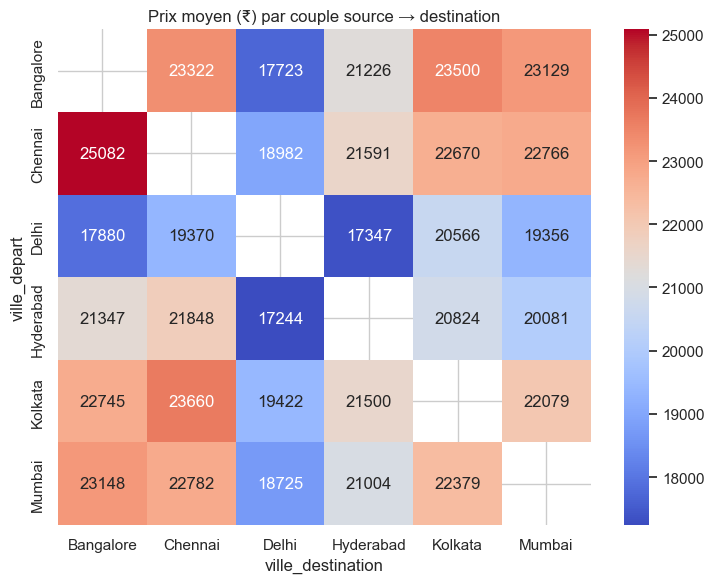

In [25]:
pvt = donnees_vols.pivot_table(index='ville_depart', columns='ville_destination',
                     values='prix', aggfunc='mean')
plt.figure(figsize=(7.5,6))
sns.heatmap(pvt, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Prix moyen (₹) par couple source → destination")
plt.tight_layout(); plt.show()

**Réponse (d).** Oui : certaines liaisons (p. ex. impliquant *Kolkata* ou *Chennai*) sont
en moyenne plus chères que d'autres. La ville d'origine et de destination influence le prix.

### (e) L'impact de la Classe sur le Prix
Vérifions l'hypothèse soulevée par le premier graphique avec une boîte à moustaches (Boxplot).

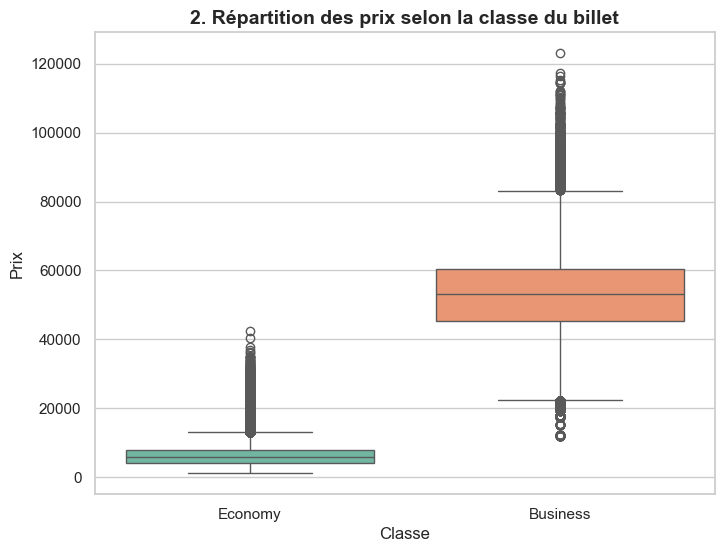

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='classe', y='prix', data=donnees_vols, palette='Set2')
plt.title('2. Répartition des prix selon la classe du billet', fontsize=14, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Prix', fontsize=12)
plt.show()

Le boxplot confirme une différence drastique et sans chevauchement entre la classe "Economy" et la classe "Business". La médiane des prix en classe Affaires est presque 10 fois supérieure à celle de la classe Économique. La variable classe sera le prédicteur le plus fort pour notre modèle de régression.

# 4) Sélection de caractéristiques cibles
Pour répondre aux objectifs du projet, nous devons réaliser deux tâches distinctes d'apprentissage automatique. Nous sélectionnons donc deux caractéristiques cibles différentes :

1. Pour la tâche de Régression :
Notre variable cible sera le prix (variable continue).
Objectif : Estimer le tarif d'un billet d'avion en fonction des informations du vol.

2. Pour la tâche de Classification :
Notre variable cible sera la classe (variable binaire : Economy ou Business).
Objectif : Prédire à quelle classe appartient un billet en fonction de ses autres attributs (prix, compagnie, durée, etc.).

NameError: name 'donnees_vols' is not defined

L'analyse de l'importance des variables confirme les observations de notre analyse exploratoire (EDA). La variable classe (Économie vs Business) écrase toutes les autres en termes de pouvoir prédictif. Viennent ensuite les variables numériques duree et jours_avant_depart, ainsi que certaines compagnies aériennes spécifiques. Les variables liées aux villes de départ/arrivée ou à certains horaires semblent avoir un impact marginal sur la prédiction du prix.

## 